# Loan Analyzer E2E Demo

This notebook provides a comprehensive walkthrough of the `loan_analyzer` project. We will cover:
1. **Data Synthesis**: Creating realistic loan data.
2. **Data Ingestion**: Loading CSVs into an auditable DuckDB environment.
3. **Integrity Validation**: Running financial invariant checks.
4. **Financial Computation**: Calculating recursive loan states and delinquency status.
5. **Forensic Auditing**: Reconciling the engine's outputs.
6. **Advanced Analytics**: Visualizing Borrower Growth and Vintage DPD trends.

## Environment Setup

First, we'll configure our environment and import the core components.

In [2]:
import os
import sys
from pathlib import Path

# Ensure the local 'src' directory is prioritized for imports
sys.path.insert(0, os.path.abspath('src'))

import pandas as pd
import plotly.graph_objects as go
from loan_analyzer import (
    DataLoader, 
    DataValidation, 
    LoanCalculation, 
    LoanAudit,
    ImpactMetrics,
    CreditMetrics,
    ChartFactory
)
from generate_test_data import generate_data

## 1. Data Generation

We use the built-in generator to create a set of CSV files (loans, borrowers, payments, etc.) to simulate a production environment.

In [3]:
DATA_DIR = "demo_data"
LENDER_ID = "DEMO_LENDER_001"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

generate_data(DATA_DIR, perfect=True, lender_id=LENDER_ID)
print(f"✅ Sample data generated in {DATA_DIR}")

✅ Sample data generated in demo_data


## 2. Ingestion & Integrity Checks

The `DataLoader` handles the mapping of CSVs to DuckDB tables, while `DataValidation` ensures that the data is financially sound (e.g., no negative principal, valid terminal states).

In [4]:
# Load data into DuckDB and create a Hive-style audit archive
loader = DataLoader(DATA_DIR, lender_id=LENDER_ID, output_format="csv")

# Run all data integrity tests
validator = DataValidation(loader)
validation_report = validator.validate_all()

if validation_report['passed'].all():
    print("✅ All data integrity checks passed.")
else:
    print("⚠️ Validation issues detected:")
    display(validation_report[validation_report['passed'] == False])

Loading actual_payments.csv into table 'actual_payments'...
Injecting lender_id 'DEMO_LENDER_001' into table 'actual_payments'...
Injecting year, month, day partitions from actual_payment_date into table 'actual_payments'...
Loading loans.csv into table 'loans'...
Injecting year, month, day partitions from origination_date into table 'loans'...
Loading borrowers.csv into table 'borrowers'...
Injecting lender_id 'DEMO_LENDER_001' into table 'borrowers'...
Injecting year, month, day partitions from signup_month into table 'borrowers'...
Loading collateral_valuation.csv into table 'collateral_valuation'...
Injecting lender_id 'DEMO_LENDER_001' into table 'collateral_valuation'...
Injecting year, month, day partitions from valuation_date into table 'collateral_valuation'...
Loading scheduled_repayments.csv into table 'scheduled_repayments'...
Injecting lender_id 'DEMO_LENDER_001' into table 'scheduled_repayments'...
Injecting year, month, day partitions from scheduled_instalment_date into 

## 3. Core Financial Pipeline

The `LoanCalculation` engine executes high-performance SQL transformations to calculate recursive monthly states for every loan and pinpoint delinquency at the instalment level.

In [5]:
calculator = LoanCalculation(validator)
calculator.run_all()
print("✅ Core calculations complete: 'loan_state' and 'instalment_delinquency' tables populated.")

Calculating recursive loan state...
✅ Loan state calculated successfully.
Saving loan_state to core_computations/loan_state in Hive format (csv)...
✅ Saved loan_state successfully.
Calculating delinquency metrics...
✅ Delinquency metrics calculated successfully.
Saving instalment_delinquency to core_computations/instalment_delinquency in Hive format (csv)...
✅ Saved instalment_delinquency successfully.

--- Full Calculation Pipeline Complete ---
✅ Core calculations complete: 'loan_state' and 'instalment_delinquency' tables populated.


## 4. Forensic Audit & Verification

Transparency is critical. We can audit individual loans to reconcile their balances month-over-month.

In [6]:
auditor = LoanAudit(calculator)
audit_passed, audit_report = auditor.validate_calculations()

if audit_passed:
    print("✅ Calculation logic verified and reconciled via automated audit.")
else:
    print("❌ Audit failed - discrepancies detected.")

# View the audited history for a sample loan
sample_loan_id = loader.get_connection().execute("SELECT loan_id FROM loans LIMIT 1").fetchone()[0]
loan_history = auditor.get_loan_audit(sample_loan_id)
display(loan_history.head())


--- Running Post-Calculation Validations ---
✅ test_continuity: Passed
✅ test_monotonicity: Passed
✅ test_non_negative: Passed
✅ Calculation logic verified and reconciled via automated audit.


,loan_id,lender_id,year,month,day,period_number,period_start,opening_principal,interest_accrued,cash_received,...,write_off_occurred,amortization,closing_principal,computed_at,days_past_due,dpd_category,scheduled_instalment_date,real_payment_date,flag_write_off_this_month,flag_prepayment_this_month
0,LOAN_001,DEMO_LENDER_001,2022,4,1,1,2022-04-01,10000.000000,0.000000,0.000000,...,0.0,0.000000,10000.000000,2026-05-20 17:30:21.460311+01:00,<NA>,NaN,NaT,NaT,<NA>,<NA>
1,LOAN_001,DEMO_LENDER_001,2022,5,1,2,2022-05-01,10000.000000,101.532125,939.865458,...,0.0,838.333333,9161.666667,2026-05-20 17:30:21.460311+01:00,30,dpd 30-59,2022-05-26,2022-06-25,0,0
2,LOAN_001,DEMO_LENDER_001,2022,6,1,3,2022-06-01,9161.666667,93.020348,939.865458,...,0.0,846.845110,8314.821557,2026-05-20 17:30:21.460311+01:00,30,dpd 30-59,2022-06-25,2022-07-25,0,0
3,LOAN_001,DEMO_LENDER_001,2022,7,1,4,2022-07-01,8314.821557,84.422150,939.865458,...,0.0,855.443308,7459.378249,2026-05-20 17:30:21.460311+01:00,30,dpd 30-59,2022-07-25,2022-08-24,0,0
4,LOAN_001,DEMO_LENDER_001,2022,8,1,5,2022-08-01,7459.378249,75.736652,939.865458,...,0.0,864.128806,6595.249443,2026-05-20 17:30:21.460311+01:00,30,dpd 30-59,2022-08-24,2022-09-23,0,0


## 5. Visualizing Key Performance Indicators

Finally, we use the metrics runners to generate interactive visualizations.

### A. Borrower Growth Trend
This dual-axis chart tracks new borrower signups vs. total cumulative borrowers over time.

Parsing impact metric: borrower_delta for target dialect: duckdb...
Saving borrower_delta to impact_metrics/borrower_delta in Hive format (parquet)...
✅ Saved borrower_delta successfully.
Resolving graph for borrower_delta using path: loan_analyzer.core.loan_system.graphs.ChartFactory.unique_borrower_delta


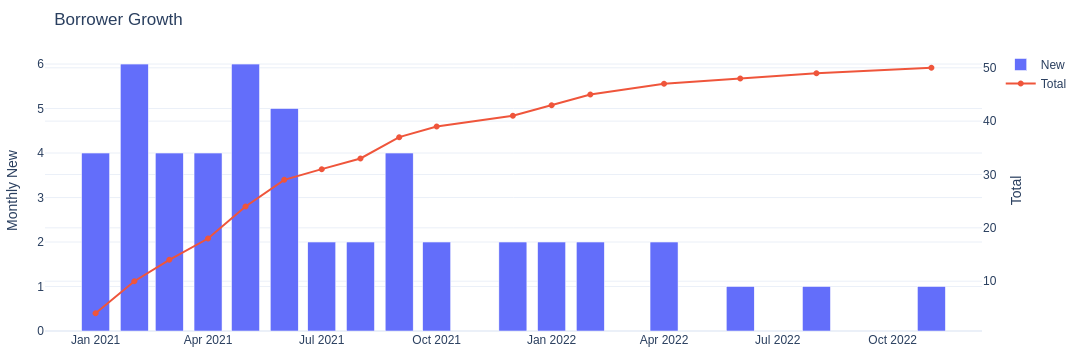

In [7]:
impact_runner = ImpactMetrics(calculator)
df_borrower = impact_runner.run_metric("borrower_delta")
fig_json = impact_runner.get_graph("borrower_delta", df_borrower)

go.Figure(fig_json).show()

### B. Vintage DPD Trend (90+)
This chart tracks the default seasoning of different loan cohorts (vintages) based on their Months on Book (MOB).

Parsing credit metric: vintage_delinquency for target dialect: duckdb...
Saving vintage_delinquency to credit_metrics/vintage_delinquency in Hive format (parquet)...
✅ Saved vintage_delinquency successfully.
Resolving graph for vintage_delinquency using path: loan_analyzer.core.loan_system.graphs.ChartFactory.vintage_dpd_trend


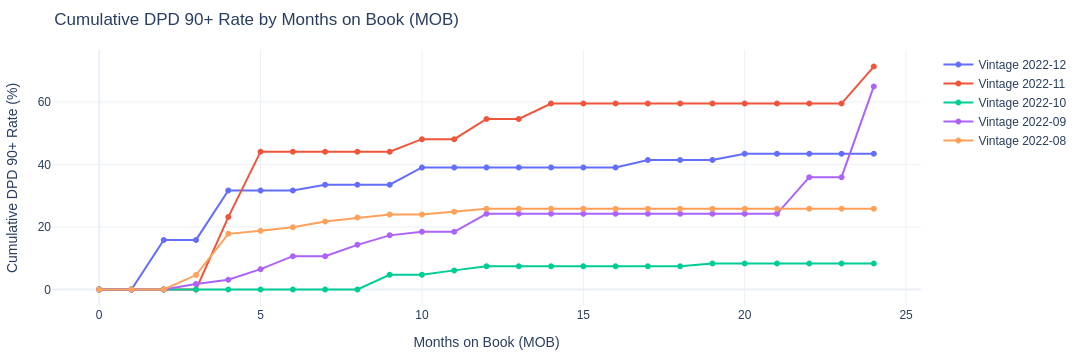

In [8]:
credit_runner = CreditMetrics(calculator)
df_vint_del = credit_runner.run_metric("vintage_delinquency")
fig_json_dpd = credit_runner.get_graph("vintage_delinquency", df_vint_del)

go.Figure(fig_json_dpd).show()

### C. Loan Grade Mix
A stacked area chart showing the evolution of the portfolio's risk profile by loan grade.

Parsing credit metric: grade_dist for target dialect: duckdb...
Saving grade_dist to credit_metrics/grade_dist in Hive format (parquet)...
✅ Saved grade_dist successfully.
Resolving graph for grade_dist using path: loan_analyzer.core.loan_system.graphs.ChartFactory.grade_dist


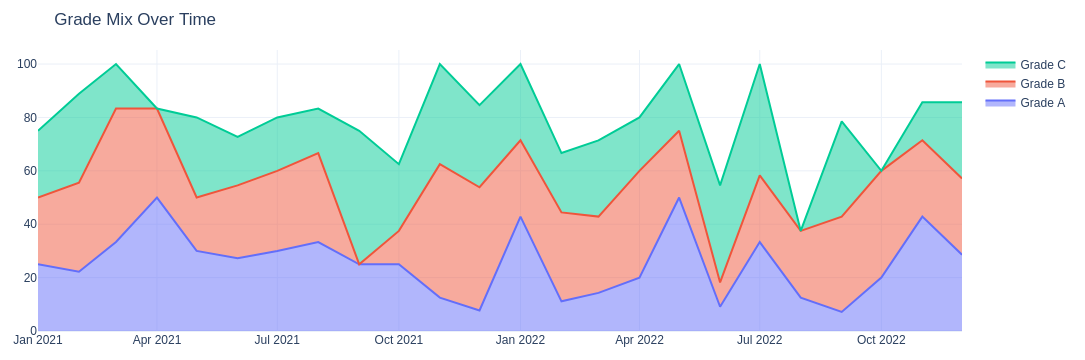

In [9]:
df_grade = credit_runner.run_metric("grade_dist")
fig_json_grade = credit_runner.get_graph("grade_dist", df_grade)

go.Figure(fig_json_grade).show()